### 1. Imports

In [ ]:

import numpy as np
import pandas as pd 
import seaborn as sns
import json
import unidecode
from matplotlib import pyplot as plt
import ast
from flaml import AutoML
from sklearn.cluster import KMeans


c:\Users\rlope\anaconda3\envs\hc_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-02 12:25:49,078	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-12-02 12:25:49,309	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [ ]:
# Evitar printar warnings
import warnings 
warnings.filterwarnings("ignore")

### 2. Load data and Overview

In [ ]:
train_df = pd.read_csv('../data/train_split.csv')
test_df = pd.read_csv('../data/test_split.csv') 

# Train & test dataframes  shape
print(train_df.shape, test_df.shape)

(110000, 70) (39867, 70)


In [ ]:
# First overview of train dataframe features/target info
train_df.info()
# # Look at top 5 rows
train_df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110000 entries, 0 to 109999
Data columns (total 70 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  110000 non-null  int64  
 1   ciudad                              110000 non-null  object 
 2   estado                              110000 non-null  object 
 3   estado_propiedad                    110000 non-null  object 
 4   dormitorios                         102884 non-null  float64
 5   banos                               106172 non-null  float64
 6   precio                              109968 non-null  float64
 7   anio_construccion                   9003 non-null    float64
 8   codigo_postal                       110000 non-null  int64  
 9   longitud                            109666 non-null  float64
 10  latitud                             109666 non-null  float64
 11  geocodificacion_deficiente

,id,ciudad,estado,estado_propiedad,dormitorios,banos,precio,anio_construccion,codigo_postal,longitud,...,construccion,numero_unidad,detalles_comunidad,pies_cuadrados,fecha_disponibilidad,oferta_especial,puntajes_movilidad,dias_en_portal_detalle,movilidad,riesgos_climaticos
0,1,Lakeland,FL,FOR_SALE,3.0,2.0,119900.0,NaN,33810,-81.97661,...,"[{""title"":""Type & style"",""values"":[""Home type:...",NaN,NaN,NaN,NaN,NaN,"{""bike_score"":null,""transit_score"":null,""walk_...",362.0,"{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
1,2,Pompano Beach,FL,FOR_SALE,3.0,2.0,290000.0,NaN,33067,-80.24621,...,"[{""title"":""Type & style"",""values"":[""Home type:...",NaN,"[{""title"":""Subdivision"",""values"":[""Edgewater C...",NaN,NaN,NaN,"{""bike_score"":null,""transit_score"":null,""walk_...",45.0,"{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
2,3,Jacksonville,FL,FOR_SALE,3.0,3.0,599000.0,NaN,32205,-81.71293,...,"[{""title"":""Type & style"",""values"":[""Home type:...",NaN,"[{""title"":""Subdivision"",""values"":[""Stockton Pl...",NaN,NaN,NaN,"{""bike_score"":null,""transit_score"":null,""walk_...",48.0,"{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."


In [ ]:
# Elimino las columnas id de ambos datasets
train_df.drop(columns=['id'], inplace=True)

test_ids_list = test_df['id'].values # Extraemos para luego usarlo en el submission 
test_df.drop(columns=['id'], inplace=True)

In [ ]:
# Train & test dataframes  shape
print(train_df.shape, test_df.shape)

(110000, 69) (39867, 69)


In [ ]:
# Determino intersección en columnas entre train y test
common_cols = train_df.columns.intersection(test_df.columns)
len(common_cols)

69

In [ ]:
# Selecciono features numéricos y categóricos
numerical_FEATURES = train_df[common_cols].select_dtypes(['int64','float64']).columns
categorical_FEATURES = train_df[common_cols].select_dtypes(['object']).columns

In [ ]:
# Visualización estadísticos descriptivos de las variables numéricas
train_df[numerical_FEATURES].describe().T.sort_values(by='std').style.background_gradient(cmap='GnBu')

,count,mean,std,min,25%,50%,75%,max
tasa_impuesto_propiedad,109963.000000,1.634174,0.310859,0.000000,1.460000,1.730000,1.840000,2.160000
dormitorios,102884.000000,2.939116,1.262672,0.000000,2.000000,3.000000,4.000000,91.000000
latitud,109666.000000,27.720004,1.485288,24.548346,26.424290,27.704355,28.708632,46.833220
longitud,109666.000000,-81.700261,1.564072,-111.477200,-82.336218,-81.614458,-80.334870,-70.615395
banos,106172.000000,2.417070,6.875272,0.000000,2.000000,2.000000,3.000000,2204.000000
conteo_vistas_recorrido,109963.000000,0.190782,15.505444,0.000000,0.000000,0.000000,0.000000,3384.000000
conteo_fotos,110000.000000,34.996864,20.516846,0.000000,21.000000,33.000000,47.000000,209.000000
dias_en_portal,109968.000000,128.431416,158.134698,-33.000000,32.000000,83.000000,168.000000,4908.000000
dias_en_portal_detalle,109886.000000,128.486531,158.168976,-33.000000,32.000000,83.000000,168.000000,4908.000000
anio_construccion,9003.000000,2008.608020,675.901256,0.000000,1988.000000,2018.000000,2025.000000,65535.000000


In [ ]:
# Podemos observar que ya hay features numéricos con demasiados valores NULOS que podemos obviar de primeras
FEATURES2DROP = [
    "datos_residenciales_alcantarillado", 
    "datos_residenciales_fuente_agua", 
    "numero_unidad",
    "pies_cuadrados",
    "fecha_disponibilidad",
    "oferta_especial", ## Hasta aqui todo nans
    "anio_construccion",
    "dias_en_portal_detalle", # Ya tiene presencia a traves de dias_en_portal
    "tamano_lote",
    ]

# Extraigo el precio de las variables FEATURES ya que es el target
TARGET = "precio"
FEATURES2DROP +=[TARGET]
numerical_FEATURES = [f for f in numerical_FEATURES if f not in FEATURES2DROP]

### 3. Univariate analysis

#### 3.1. Numerical features
Es interesante ver la distribución de los numerical features del train y test dataset para ver si hay diferencias significativas entre los mismos

,count,mean,std,min,25%,50%,75%,max
precio,109968.0,745150.713689,2.191973e+06,0.0,249900.0,398997.0,650000.0,285000000.0


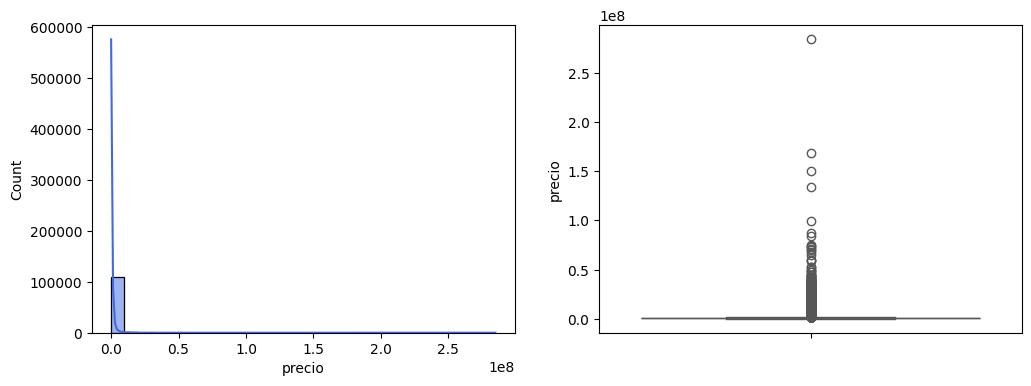

In [ ]:
# Visualización variable target
fig, axes = plt.subplots(1, 2, figsize = (12,4))
sns.histplot(train_df[TARGET], kde=True, bins = 30, color="royalblue",label="train", ax= axes[0])
sns.boxplot(train_df[TARGET],color="royalblue", label="train", ax= axes[1])
pd.DataFrame(train_df[TARGET].describe()).T

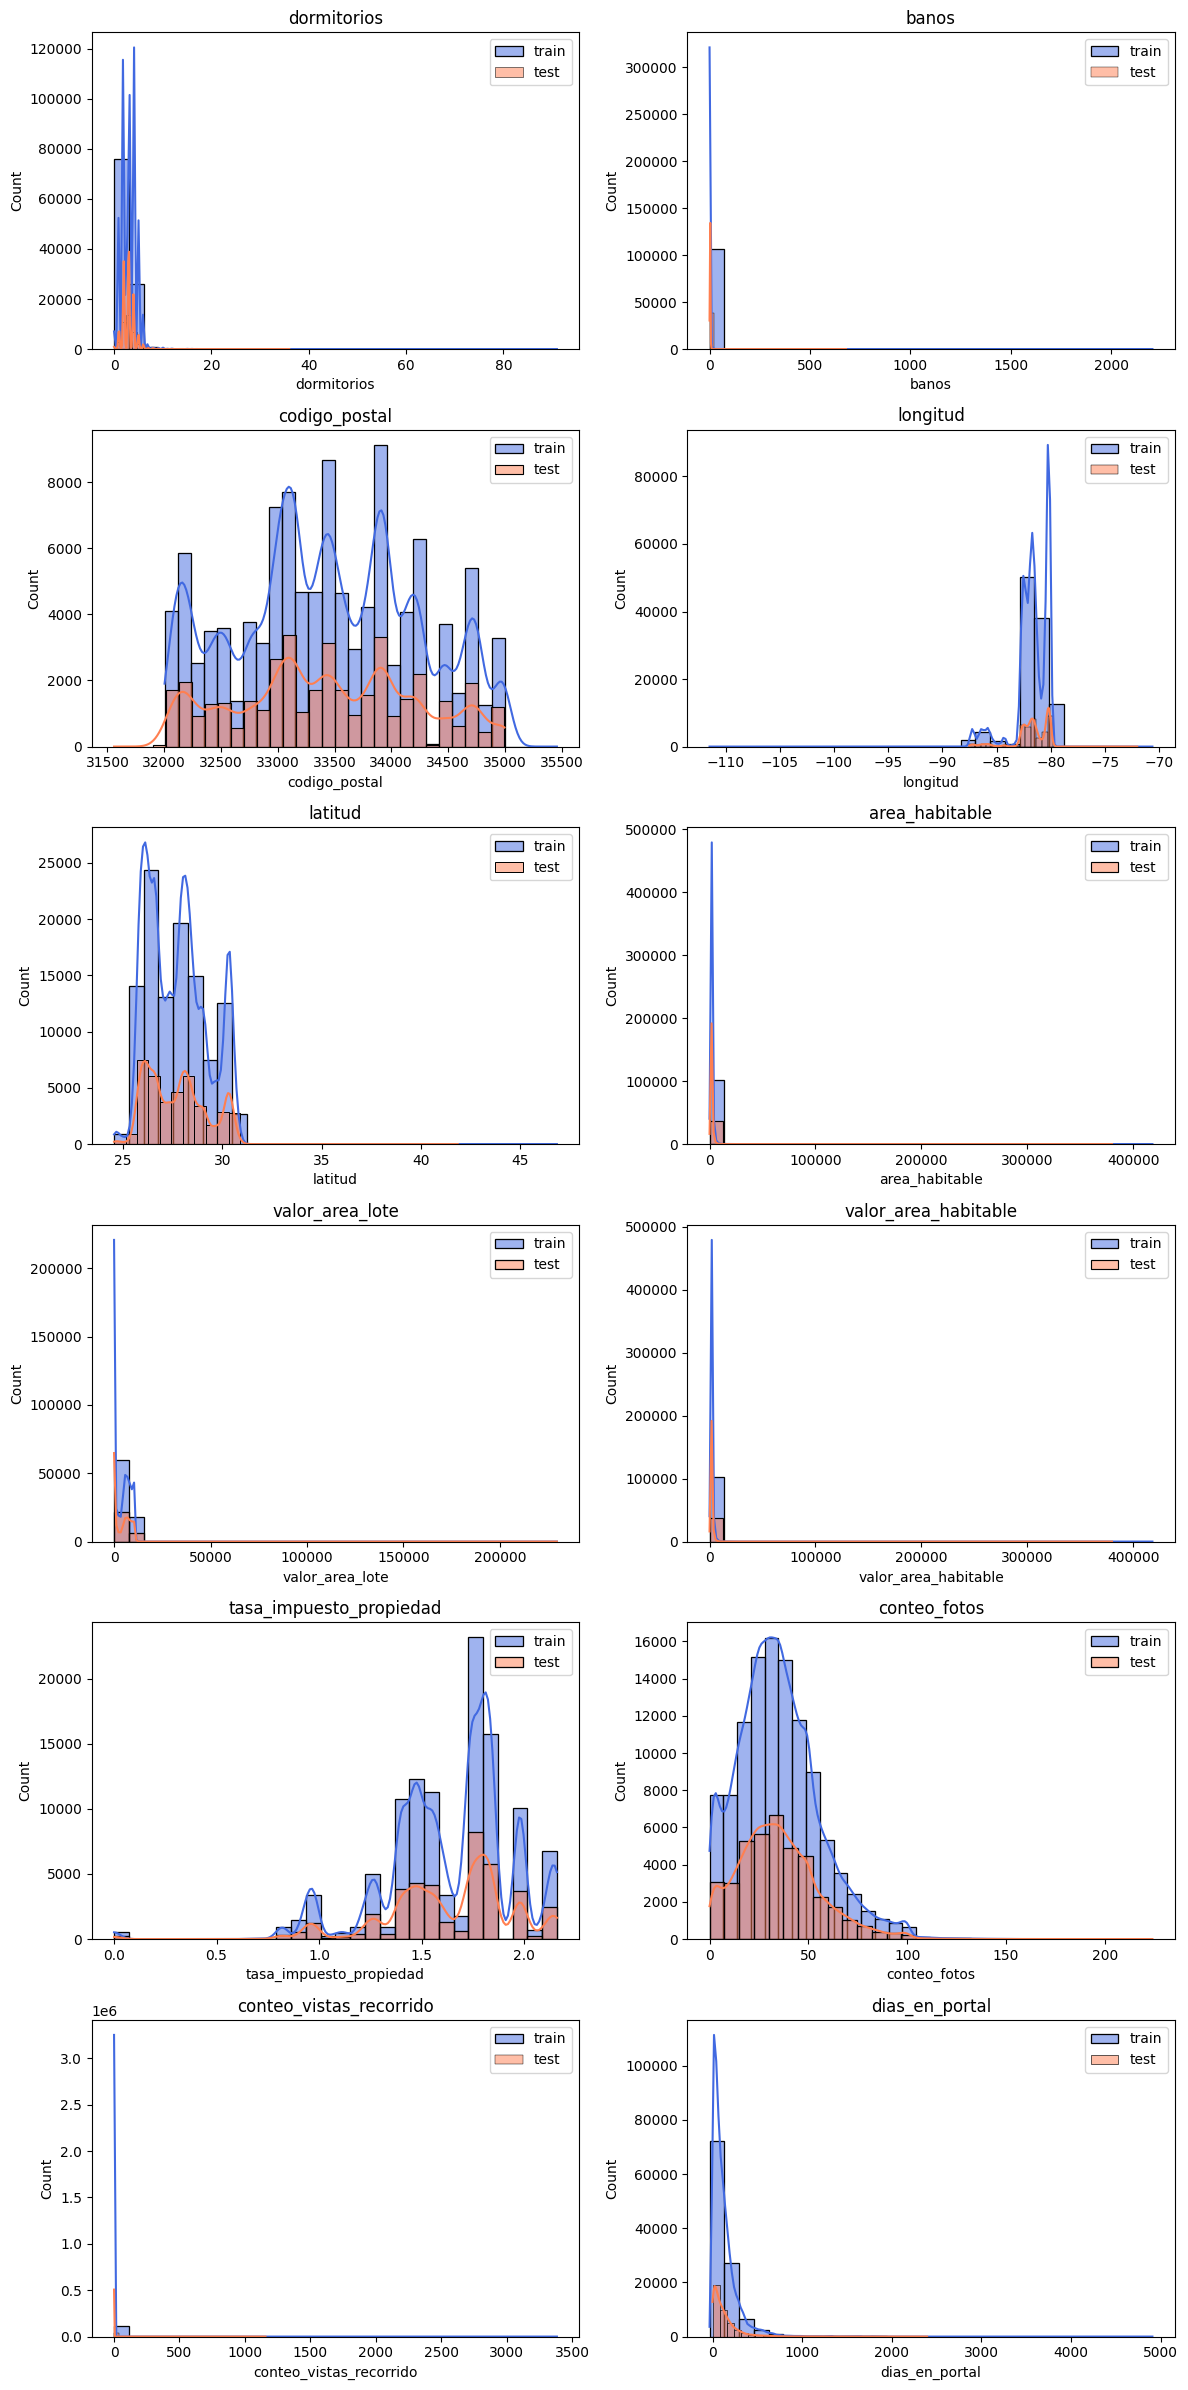

In [ ]:
numerical_FEATURES = train_df[numerical_FEATURES].describe().T.index.tolist()
n_cols = 2
n_rows = (len(numerical_FEATURES) + n_cols - 1) // n_cols  # redondeo hacia arriba
fig, axes = plt.subplots(n_rows, n_cols, figsize = (12,n_rows*4))
axes = axes.flatten()  # facilita indexar los subplots

for i, feature in enumerate(numerical_FEATURES):
    sns.histplot(train_df[feature], kde=True, bins = 30, ax=axes[i], color="royalblue",label="train")
    sns.histplot(test_df[feature], kde=True, bins=30, ax = axes[i], color="coral",label="test")
    axes[i].set_title(feature)
    axes[i].legend()

# Apagar ejes vacíos (si los hay)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

Como puede observarse en los gráficos hay muchos features skewed, por ejemplo: 

Right skewed: 
- Dormitorios
- banos
- precio
- area habitable
- tamano lote
- valor_area_lote
- valor_area_habitable
- conteo_vistas_recorrido
- dias en portal
- dias_en_portal_detalle

Tendrá que decidirse que hacer con los valores atípicos para los features right skewed y como inputar los NaN. 
    - Una opción es sustituir los valores atípicos (outliers) por la mediana de se feature al igual que los NaN. 

**El codigo postal es una variable numérica pero no debería usarse como variable continua porque no tiene relacion ordinal, las distancias numericas no representan distancias geograficas reales. Lo mejor es hacer one hot encoding**

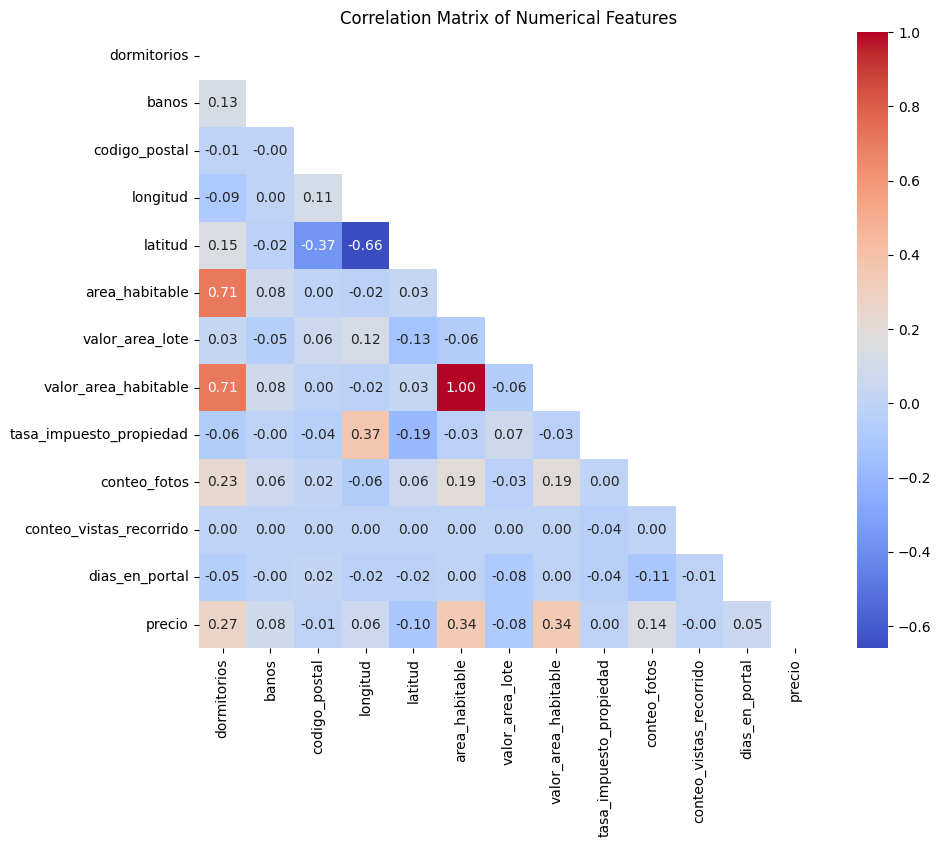

In [ ]:
# Correlación entre variables numéricas
mask = np.triu(np.ones_like(train_df[numerical_FEATURES + ['precio']].corr().round(2), dtype=bool))
correlation_matrix = train_df[numerical_FEATURES + ['precio']].corr().round(2)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm",mask=mask, fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

Como puede verse en la matriz de correlación, hay variables altamente correladas: 
- Area habitable y valor area habitable estan completamente correladas. 
- Area habitable y valor area habitable con dormitorios
- Longitud con tasa de impuesto propiedad también están correladas 
- Dormitorios, conteo_fotos, y area habitable estan correlacionados con el valor del precio

In [ ]:
# Elimino feature que es una copia del otro y elimino valor area lote que tiene muchos nans
numerical_FEATURES = [f for f in numerical_FEATURES if f not in ['valor_area_habitable', 'valor_area_lote']]

In [ ]:
train_df[numerical_FEATURES].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110000 entries, 0 to 109999
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   dormitorios              102884 non-null  float64
 1   banos                    106172 non-null  float64
 2   codigo_postal            110000 non-null  int64  
 3   longitud                 109666 non-null  float64
 4   latitud                  109666 non-null  float64
 5   area_habitable           102508 non-null  float64
 6   tasa_impuesto_propiedad  109963 non-null  float64
 7   conteo_fotos             110000 non-null  int64  
 8   conteo_vistas_recorrido  109963 non-null  float64
 9   dias_en_portal           109968 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 8.4 MB


#### 3.2. Imputación de variables numericas

- Primero imputo variables que requieran calculos en escala natural ya que sino los grupos quedarán distorsionados 
- Posteriormente tarnsformaremos a log1p

In [ ]:
# Quitar los registros del train que tengan NaN
train_df = train_df[~train_df['precio'].isna()]

In [ ]:
# Mediana por (baños, habitaciones)
median_map_full = train_df.groupby(["banos", "dormitorios"])["area_habitable"].median()

# Mediana solo por habitaciones
median_map_rooms = train_df.groupby(["dormitorios"])["area_habitable"].median()

# Mediana solo por baños
median_map_bath = train_df.groupby(["banos"])["area_habitable"].median()

# Mediana global del train
global_median = train_df["area_habitable"].median()

def impute_area(row):
    if not pd.isna(row["area_habitable"]):
        return row["area_habitable"]

    # 1. Por (baños, habitaciones)
    key_full = (row["banos"], row["dormitorios"])
    val = median_map_full.get(key_full)
    if not pd.isna(val):
        return val

    # 2. Solo por habitaciones
    val = median_map_rooms.get(row["dormitorios"])
    if not pd.isna(val):
        return val

    # 3. Solo por baños
    val = median_map_bath.get(row["banos"])
    if not pd.isna(val):
        return val

    # 4. Mediana global del train
    return global_median


def fill_nans_with_median(train_df, test_df, feature): 
    mediana_dorm = train_df[feature].median()
    train_df[feature] = train_df[feature].fillna(mediana_dorm)
    test_df[feature] = test_df[feature].fillna(mediana_dorm)
    return train_df, test_df

def fill_nans_with_mode(train_df, test_df, feature): 
    mediana_dorm = train_df[feature].mode()[0]
    train_df[feature] = train_df[feature].fillna(mediana_dorm)
    test_df[feature] = test_df[feature].fillna(mediana_dorm)
    return train_df, test_df


In [ ]:
# Variables numéricas
# Imputar NaNs tanto en train como en test
train_df, test_df = fill_nans_with_mode(train_df, test_df, 'dormitorios')
train_df, test_df = fill_nans_with_mode(train_df, test_df, 'banos')
train_df, test_df = fill_nans_with_mode(train_df, test_df, 'dias_en_portal')
train_df, test_df = fill_nans_with_mode(train_df, test_df, 'conteo_vistas_recorrido')


train_df["area_habitable"] = train_df.apply(impute_area, axis=1)
test_df["area_habitable"] = test_df.apply(impute_area, axis=1)

# Hay casos donde el value_counts es 1 o hay discrepancias en algunas casuísticas. 
# Por lo que decido seleccionar la zona horaria por ciudad con más frecuencia de aparición. 
zona_horaria_dominante = (train_df.groupby("codigo_postal")["zona_horaria"].agg(lambda x: x.value_counts().idxmax()))
train_df['zona_horaria'] = train_df['codigo_postal'].map(zona_horaria_dominante)
test_df['zona_horaria'] = test_df['codigo_postal'].map(zona_horaria_dominante)


## Tasa de impuesto de propiedad
# Ajustarla por codigo_postal a la mediana del valor del codigo postal

cp_impuesto_dict = dict(train_df.groupby('codigo_postal')['tasa_impuesto_propiedad'].median())
train_df['tasa_impuesto_propiedad'] = train_df['tasa_impuesto_propiedad'].fillna(train_df['codigo_postal'].map(cp_impuesto_dict))
# Si se mantiene algun NaN sustituir por la mediana global
train_df['tasa_impuesto_propiedad'] = train_df['tasa_impuesto_propiedad'].fillna(train_df['tasa_impuesto_propiedad'].median())

test_df['tasa_impuesto_propiedad'] = test_df['tasa_impuesto_propiedad'].fillna(test_df['codigo_postal'].map(cp_impuesto_dict))
test_df['tasa_impuesto_propiedad'] = test_df['tasa_impuesto_propiedad'].fillna(train_df['tasa_impuesto_propiedad'].median())


# Para latitud y longitud considerar la mediana por zona
media_lat_por_cp = dict(train_df.groupby('codigo_postal')['latitud'].mean())
media_long_por_cp = dict(train_df.groupby('codigo_postal')['longitud'].mean())

train_df['latitud'] = train_df['latitud'].fillna(train_df['codigo_postal'].map(media_lat_por_cp))
train_df['longitud'] = train_df['longitud'].fillna(train_df['codigo_postal'].map(media_long_por_cp))

test_df['latitud'] = test_df['latitud'].fillna(test_df['codigo_postal'].map(media_lat_por_cp))
test_df['longitud'] = test_df['longitud'].fillna(test_df['codigo_postal'].map(media_long_por_cp))

In [ ]:
train_df[numerical_FEATURES].info()

<class 'pandas.core.frame.DataFrame'>
Index: 109968 entries, 0 to 109999
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   dormitorios              109968 non-null  float64
 1   banos                    109968 non-null  float64
 2   codigo_postal            109968 non-null  int64  
 3   longitud                 109968 non-null  float64
 4   latitud                  109968 non-null  float64
 5   area_habitable           109968 non-null  float64
 6   tasa_impuesto_propiedad  109968 non-null  float64
 7   conteo_fotos             109968 non-null  int64  
 8   conteo_vistas_recorrido  109968 non-null  float64
 9   dias_en_portal           109968 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 9.2 MB


In [ ]:
test_df[numerical_FEATURES].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39867 entries, 0 to 39866
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   dormitorios              39867 non-null  float64
 1   banos                    39867 non-null  float64
 2   codigo_postal            39867 non-null  int64  
 3   longitud                 39867 non-null  float64
 4   latitud                  39867 non-null  float64
 5   area_habitable           39867 non-null  float64
 6   tasa_impuesto_propiedad  39867 non-null  float64
 7   conteo_fotos             39867 non-null  int64  
 8   conteo_vistas_recorrido  39867 non-null  float64
 9   dias_en_portal           39867 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 3.0 MB


In [ ]:

## Variables Binarias 
## Geocodificacion deficiente
# Aunque la mayoria de los datos son NaN consideraremos que la geocodificación es precisa
train_df['geocodificacion_deficiente'] = train_df['geocodificacion_deficiente'].fillna(False)
test_df['geocodificacion_deficiente'] = test_df['geocodificacion_deficiente'].fillna(False)

## Direccion no divulgada
# La gran mayoría de los casos son False, por lo que los NaNs los sustituiremos por False
train_df['direccion_no_divulgada'] = train_df['direccion_no_divulgada'].fillna(False)
test_df['direccion_no_divulgada'] = test_df['direccion_no_divulgada'].fillna(False)

## Es constructor premier
# La gran mayoria de los casos son False, por lo que los NaNs los sustituiremos por False
train_df['es_constructor_premier'] = train_df['es_constructor_premier'].fillna(False)
test_df['es_constructor_premier'] = test_df['es_constructor_premier'].fillna(False)

## Tiene video publico 
# Solo se informan los False por lo que entendemos que los NaN son True
train_df['tiene_video_publico'] = train_df['tiene_video_publico'].fillna(True)
test_df['tiene_video_publico'] = test_df['tiene_video_publico'].fillna(True)

## url_tour_virtual_terceros
# Rellenamos los Nan con el valor con mayor frecuencia --> False
train_df['url_tour_virtual_tercero_aprobado'] = train_df['url_tour_virtual_tercero_aprobado'].fillna(False)
test_df['url_tour_virtual_tercero_aprobado'] = test_df['url_tour_virtual_tercero_aprobado'].fillna(False)

In [ ]:
# Hay un negativo en dias en portal --> transformo en valor absoluto 
train_df['dias_en_portal'] = train_df['dias_en_portal'].apply(lambda x: np.abs(x))
test_df['dias_en_portal'] = test_df['dias_en_portal'].apply(lambda x: np.abs(x))


In [ ]:
def transformacion_log1p_variables_right_skewed_train_test(train_df, test_df, feature): 
    train_df[feature] = train_df[feature].apply(lambda x: np.log1p(x))
    test_df[feature] = test_df[feature].apply(lambda x: np.log1p(x))
    return (train_df, test_df)

# Como dias en portal es una variable right skewed sustituyo valores que superen el limite de outliers por la mediana 
train_df, test_df = transformacion_log1p_variables_right_skewed_train_test(train_df, test_df, 'dias_en_portal')
train_df, test_df = transformacion_log1p_variables_right_skewed_train_test(train_df, test_df, 'dormitorios')
train_df, test_df = transformacion_log1p_variables_right_skewed_train_test(train_df, test_df, 'banos')
train_df, test_df = transformacion_log1p_variables_right_skewed_train_test(train_df, test_df, 'area_habitable')
# Otras variables a preprocesar
train_df, test_df = transformacion_log1p_variables_right_skewed_train_test(train_df, test_df, 'conteo_vistas_recorrido')

In [ ]:
train_df[numerical_FEATURES].info()

<class 'pandas.core.frame.DataFrame'>
Index: 109968 entries, 0 to 109999
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   dormitorios              109968 non-null  float64
 1   banos                    109968 non-null  float64
 2   codigo_postal            109968 non-null  int64  
 3   longitud                 109968 non-null  float64
 4   latitud                  109968 non-null  float64
 5   area_habitable           109968 non-null  float64
 6   tasa_impuesto_propiedad  109968 non-null  float64
 7   conteo_fotos             109968 non-null  int64  
 8   conteo_vistas_recorrido  109968 non-null  float64
 9   dias_en_portal           109968 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 9.2 MB


In [ ]:
test_df[numerical_FEATURES].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39867 entries, 0 to 39866
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   dormitorios              39867 non-null  float64
 1   banos                    39867 non-null  float64
 2   codigo_postal            39867 non-null  int64  
 3   longitud                 39867 non-null  float64
 4   latitud                  39867 non-null  float64
 5   area_habitable           39867 non-null  float64
 6   tasa_impuesto_propiedad  39867 non-null  float64
 7   conteo_fotos             39867 non-null  int64  
 8   conteo_vistas_recorrido  39867 non-null  float64
 9   dias_en_portal           39867 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 3.0 MB


In [ ]:
FEATURES2CONSIDER = numerical_FEATURES + ['zona_horaria','geocodificacion_deficiente','direccion_no_divulgada','es_constructor_premier','tiene_video_publico','url_tour_virtual_tercero_aprobado']

In [ ]:
train_df[FEATURES2CONSIDER].info()

<class 'pandas.core.frame.DataFrame'>
Index: 109968 entries, 0 to 109999
Data columns (total 16 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   dormitorios                        109968 non-null  float64
 1   banos                              109968 non-null  float64
 2   codigo_postal                      109968 non-null  int64  
 3   longitud                           109968 non-null  float64
 4   latitud                            109968 non-null  float64
 5   area_habitable                     109968 non-null  float64
 6   tasa_impuesto_propiedad            109968 non-null  float64
 7   conteo_fotos                       109968 non-null  int64  
 8   conteo_vistas_recorrido            109968 non-null  float64
 9   dias_en_portal                     109968 non-null  float64
 10  zona_horaria                       109968 non-null  object 
 11  geocodificacion_deficiente         109968 no

In [ ]:
# Imputacion manual codigo postal test

manual_cp_zona_horaria = {
    32330: 'America/New_York',
    32083: 'America/New_York', 
    33845: 'America/New_York', 
    33877: 'America/New_York', 
    31558: 'America/New_York',
    32631: 'America/New_York' }

test_df['zona_horaria'].fillna(test_df['zona_horaria'].map(manual_cp_zona_horaria))

In [ ]:
test_df[FEATURES2CONSIDER].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39867 entries, 0 to 39866
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   dormitorios                        39867 non-null  float64
 1   banos                              39867 non-null  float64
 2   codigo_postal                      39867 non-null  int64  
 3   longitud                           39867 non-null  float64
 4   latitud                            39867 non-null  float64
 5   area_habitable                     39867 non-null  float64
 6   tasa_impuesto_propiedad            39867 non-null  float64
 7   conteo_fotos                       39867 non-null  int64  
 8   conteo_vistas_recorrido            39867 non-null  float64
 9   dias_en_portal                     39867 non-null  float64
 10  zona_horaria                       7 non-null      object 
 11  geocodificacion_deficiente         39867 non-null  boo

In [ ]:
print('a')

In [30]:
test_df[test_df['zona_horaria'].isna()][['codigo_postal','zona_horaria']]

,codigo_postal,zona_horaria
3993,32330,NaN
5282,32083,NaN
6678,33845,NaN
12739,32631,NaN
16683,33877,NaN
26129,32083,NaN
27127,31558,NaN


In [ ]:
test_df[test_df['codigo_postal']== 31558][]

,ciudad,estado,estado_propiedad,dormitorios,banos,precio,anio_construccion,codigo_postal,longitud,latitud,...,construccion,numero_unidad,detalles_comunidad,pies_cuadrados,fecha_disponibilidad,oferta_especial,puntajes_movilidad,dias_en_portal_detalle,movilidad,riesgos_climaticos
27127,Saint Marys,FL,FOR_SALE,1.609438,1.609438,NaN,2025.0,31558,-81.6081,30.757217,...,"[{""title"":""Type & style"",""values"":[""Home type:...",NaN,"[{""title"":""Subdivision"",""values"":[""Osprey Cove...",NaN,NaN,NaN,"{""bike_score"":null,""transit_score"":null,""walk_...",42.0,"{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."


In [33]:
test_df['zona_horaria'].unique()

array(['America/New_York', 'America/Chicago', nan], dtype=object)

Generar nuevos features: 
- baños / dormitorios

- area_habitable / dormitorios

- edad_propiedad * baños

- log(area_lote) – log(area_habitable)

In [25]:
from sklearn.model_selection import train_test_split
# Usar autogluon 
from autogluon.tabular import TabularPredictor

In [26]:

X = train_df[[f for f in train_df.columns if f not in ['precio']]]
y = train_df['precio'].apply(lambda x: np.log1p(x))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# AutoGluon espera un DataFrame completo con la columna objetivo
train_data = X_train.copy()
train_data['target'] = y_train

test_data = X_test.copy()
test_data['target'] = y_test

In [31]:


# Definir el predictor
predictor = TabularPredictor(label='target', eval_metric='mae').fit(
    train_data=train_data,
    time_limit=1200,  # tiempo máximo en segundos
    # presets='best_quality'  # opcional: hace un entrenamiento más completo
)

No path specified. Models will be saved in: "AutogluonModels\ag-20251127_200702"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          12
Memory Avail:       5.30 GB / 15.93 GB (33.3%)
Disk Space Avail:   82.34 GB / 222.73 GB (37.0%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme' : New in v1.4: Massively better than 'best' on datasets <30000 samples by using new models meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, and TabM. Absolute best accuracy. Requires a GPU. Recommended 64 GB CPU memory and 32+ GB GPU memory.
	presets='best'    : Maximize accu

[1000]	valid_set's l1: 0.234542
[2000]	valid_set's l1: 0.226452
[3000]	valid_set's l1: 0.223027
[4000]	valid_set's l1: 0.220269
[5000]	valid_set's l1: 0.218872
[6000]	valid_set's l1: 0.217553
[7000]	valid_set's l1: 0.216912
[8000]	valid_set's l1: 0.215945
[9000]	valid_set's l1: 0.2153
[10000]	valid_set's l1: 0.214711


	-0.2147	 = Validation score   (-mean_absolute_error)
	182.29s	 = Training   runtime
	0.58s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 666.10s of the 666.10s of remaining time.
	Fitting with cpus=6, gpus=0, mem=0.9/5.4 GB


[1000]	valid_set's l1: 0.234047
[2000]	valid_set's l1: 0.228186
[3000]	valid_set's l1: 0.22516
[4000]	valid_set's l1: 0.22384
[5000]	valid_set's l1: 0.222943
[6000]	valid_set's l1: 0.222412
[7000]	valid_set's l1: 0.222298
[8000]	valid_set's l1: 0.221905
[9000]	valid_set's l1: 0.221566
[10000]	valid_set's l1: 0.221368


	-0.2214	 = Validation score   (-mean_absolute_error)
	190.13s	 = Training   runtime
	0.7s	 = Validation runtime
Fitting model: RandomForestMSE ... Training model for up to 474.44s of the 474.44s of remaining time.
	Fitting with cpus=12, gpus=0, mem=0.1/5.3 GB
	-0.2634	 = Validation score   (-mean_absolute_error)
	251.16s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 223.12s of the 223.12s of remaining time.
	Fitting with cpus=6, gpus=0, mem=2.0/5.2 GB
	Ran out of time, early stopping on iteration 675.
	-0.2573	 = Validation score   (-mean_absolute_error)
	222.88s	 = Training   runtime
	0.12s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 360.00s of the 0.05s of remaining time.
	Ensemble Weights: {'LightGBMXT': 0.542, 'LightGBM': 0.333, 'RandomForestMSE': 0.125}
	-0.2087	 = Validation score   (-mean_absolute_error)
	0.04s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training 

In [32]:
results = predictor.evaluate(test_data)
print(results)

{'mean_absolute_error': -0.20595268817502668, 'root_mean_squared_error': np.float64(-0.34413419596425093), 'mean_squared_error': -0.11842834483196145, 'r2': 0.9252135219216338, 'pearsonr': 0.9621379065254463, 'median_absolute_error': -0.1327964055009856}


In [ ]:
test_df.drop(columns=['precio'])

(39867, 68)

In [37]:
y_test_predicted = predictor.predict(test_df.drop(columns=['precio']))

In [38]:
# Transformación inversa a escala original
final_y_pred = np.expm1(y_test_predicted)

In [39]:
submission_df = pd.DataFrame(test_ids_list)
submission_df['precio'] = final_y_pred
submission_df = submission_df.rename(columns={0:'id'})
submission_df.head(3)

,id,precio
0,110001,905976.00000
1,110002,425493.03125
2,110003,191787.84375


In [40]:
submission_df.to_csv('../data/submission4.csv',index=False)

In [ ]:
test_df.shape

(39867, 738)